In [2]:
import pandas as pd
import yfinance as yf

In [3]:
PERIOD = "10y"

In [4]:
# Get QQQ tickers from csv

csv_path = './qqq_holdings.csv'
df = pd.read_csv(csv_path)
tickers = df["Ticker"].str.strip().tolist()
# print(len(tickers), tickers[:10])

In [5]:
# get historical price and volume data for tickers in QQQ
raw = yf.download(tickers=tickers, period=PERIOD, auto_adjust=True)
prices = raw['Close']
volumes = raw['Volume']
ticker_data = prices

[*********************100%***********************]  101 of 101 completed


In [6]:
ticker_data

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
Date,,,,,,,,,,,,,,,,,,,,,
2016-05-09,21.143072,NaN,94.610001,45.552830,70.143135,58.790001,45.969624,57.810001,17.779251,3.650000,...,34.689999,43.290905,74.140877,88.059998,28.150000,70.230003,24.256649,19.221395,30.260813,NaN
2016-05-10,21.286621,NaN,96.519997,46.270405,71.221527,59.570000,45.800648,57.439999,17.859703,3.640000,...,34.770000,43.838596,75.084694,89.080002,29.309999,72.610001,25.182024,19.176790,30.407852,NaN
2016-05-11,21.079273,NaN,96.099998,45.981724,69.748817,59.029999,45.913303,53.820000,17.886520,3.650000,...,35.700001,43.838596,73.845345,83.629997,28.969999,71.610001,24.112265,18.648863,30.422550,NaN
2016-05-12,20.584812,NaN,95.959999,45.280659,69.644188,58.060001,46.230148,52.369999,17.546844,3.590000,...,36.290001,43.481075,74.179031,82.099998,28.139999,71.050003,23.862879,18.772417,30.768093,NaN
2016-05-13,20.625832,NaN,95.970001,45.132202,69.016479,57.869999,46.194923,52.549999,17.528971,3.670000,...,36.959999,43.450657,73.483093,81.379997,27.980000,70.650002,23.259087,18.236061,30.665171,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-04,276.829987,138.860001,253.960007,397.019989,211.320007,247.539993,133.689102,297.929993,391.380005,341.540009,...,225.179993,279.470001,178.679993,429.850006,26.959999,127.889999,442.359985,130.081757,81.169998,142.199997
2026-05-05,284.179993,139.729996,255.619995,404.769989,210.600006,249.429993,136.051926,301.109985,410.820007,355.260010,...,223.110001,281.000000,180.449997,424.359985,27.219999,128.880005,465.260010,130.540863,81.449997,141.360001
2026-05-06,287.510010,139.880005,250.169998,415.630005,207.199997,243.080002,131.604233,303.000000,428.619995,421.390015,...,222.000000,289.440002,170.940002,427.649994,27.200001,122.629997,483.149994,129.832230,80.550003,138.830002


In [7]:
def calculate_52_wk_trend(prices, n=252, lag=20):
    # calculate OLS slope using 52 week rolling window
    j = pd.Series(range(len(prices)), index=prices.index, dtype="float64")
    sum_y = prices.rolling(n).sum()
    sum_jy = prices.mul(j, axis=0).rolling(n).sum()
    mean_x = (n - 1) / 2
    var_x = n * (n ** 2 - 1) / 12
    s_xy = sum_jy - sum_y.mul(j - n + 1, axis=0)
    slope = (s_xy - mean_x * sum_y) / var_x
    return slope.shift(lag)


def pct_above_260d_low(prices, n=260, lag=20):
    return (prices / prices.rolling(n).min() - 1).shift(lag)


def wk_price_oscillator(prices, short=20, long=252, lag=20):
    ma_short = prices.rolling(short).mean()
    ma_long = prices.rolling(long).mean()
    return (ma_short / ma_long - 1).shift(lag)


def wk_39_return(prices, n=195, lag=20):
    return prices.pct_change(n).shift(lag)


def wk_51_volume_price_trend(prices, volumes, n=255, lag=20):
    # VPT is the cumulative sum of volume * daily return
    # the 51-week factor is the change in VPT over the trailing n trading days.
    vpt = (volumes * prices.pct_change()).cumsum()
    return vpt.diff(n).shift(lag)


In [8]:
def cross_sectional_zscore(df):
    # Row-wise z-score: subtract the cross-sectional mean and divide by the
    # cross-sectional std. NaNs are excluded automatically by pandas.
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1, ddof=0), axis=0)

# BME = business month end
def monthly_z_score(prices, volumes, freq="BME"):
    factors = {
        "trend_52w":     calculate_52_wk_trend(prices),
        "pct_above_low": pct_above_260d_low(prices),
        "oscillator":    wk_price_oscillator(prices),
        "ret_39w":       wk_39_return(prices),
        "vpt_51w":       wk_51_volume_price_trend(prices, volumes),
    }
    monthly = {name: f.resample(freq).last() for name, f in factors.items()}
    z_per_factor = {name: cross_sectional_zscore(m) for name, m in monthly.items()}
    # Stack the five z-score frames on a (factor, date) MultiIndex, then
    # collapse across the factor level to get the equal-weighted composite.
    stacked = pd.concat(z_per_factor, names=["factor", "date"])
    composite = stacked.groupby(level="date").mean()
    return composite, z_per_factor


monthly_z, factor_z = monthly_z_score(prices, volumes)
monthly_z.tail(10)

Ticker,AAPL,ABNB,ADBE,ADI,ADP,ADSK,AEP,ALNY,AMAT,AMD,...,TTWO,TXN,VRSK,VRTX,WBD,WDAY,WDC,WMT,XEL,ZS
date,,,,,,,,,,,,,,,,,,,,,
2025-08-29,-0.644129,-0.351590,-1.239721,-0.239470,-0.236730,-0.239726,-0.161249,0.316987,-0.303737,0.352702,...,0.372636,-0.348764,-0.303109,-0.462560,0.911682,-0.559578,0.735580,-0.009704,-0.143649,0.691107
2025-09-30,-0.317174,-0.443136,-1.283846,-0.020865,-0.308504,-0.272304,-0.092203,1.339381,-0.517655,0.439231,...,0.296432,-0.322599,-0.512636,-0.794745,0.436445,-0.660711,1.113351,-0.079588,-0.225799,0.525446
2025-10-31,-0.205468,-0.584957,-1.083015,-0.133715,-0.466837,-0.261134,-0.187850,1.020125,-0.064916,0.282857,...,0.251100,-0.484326,-0.647782,-0.721904,1.803998,-0.631539,2.242834,-0.240420,-0.181808,0.506361
2025-11-28,-0.020412,-0.520963,-1.030577,-0.221950,-0.587784,-0.361539,-0.100353,0.929629,0.097222,1.767495,...,0.134120,-0.624888,-0.775513,-0.659399,1.981442,-0.596653,2.181699,-0.261084,-0.127963,0.532946
2025-12-31,0.110894,-0.560823,-0.947859,-0.059153,-0.647802,-0.292456,-0.126654,0.907631,0.411648,1.591881,...,-0.100002,-0.536145,-0.780235,-0.587426,2.155372,-0.648033,2.690176,-0.179281,-0.190134,0.105497
2026-01-30,0.096254,-0.360476,-0.721893,0.095789,-0.633381,-0.301022,-0.219311,0.465237,0.507822,1.419225,...,-0.101704,-0.448572,-0.795219,-0.514606,2.593466,-0.635013,2.886479,-0.104956,-0.306878,-0.237256
2026-02-27,0.013461,-0.293302,-0.680576,0.185299,-0.544549,-0.390634,-0.230764,0.133501,0.658723,1.308409,...,-0.198159,-0.195037,-0.669546,-0.403001,1.836486,-0.595539,2.921211,-0.112944,-0.283323,-0.379051
2026-03-31,0.060693,-0.278567,-0.621796,0.228374,-0.539118,-0.396707,-0.110413,-0.089581,0.614445,0.861781,...,-0.338666,-0.119904,-0.594413,-0.274761,1.647816,-0.626631,2.042595,0.008767,-0.169001,-0.531984
2026-04-30,0.087065,-0.218862,-0.602088,0.200515,-0.537453,-0.382400,-0.030551,-0.181815,0.639903,0.845926,...,-0.356639,-0.154224,-0.558409,-0.208138,1.530002,-0.655310,2.085490,0.044220,-0.118993,-0.662086


In [15]:
def select_baskets(monthly_z, n_long=10, n_short=10):
    # Pick top-N longs / bottom-N shorts and weight every pick by the
    # magnitude of its z-score (conviction). Weights are normalized across
    # *both legs together* so each leg's share of the portfolio is
    # proportional to how much conviction it actually carries. This avoids
    # the 50/50 dollar-neutral split that would let a single high-conviction
    # short dominate an otherwise broad, high-conviction long book.
    valid_count = monthly_z.count(axis=1)
    z = monthly_z.loc[valid_count >= n_long + n_short]

    long_rank = z.rank(axis=1, ascending=False, method="first")
    short_rank = z.rank(axis=1, ascending=True, method="first")
    long_mask = long_rank <= n_long
    short_mask = short_rank <= n_short

    # Raw conviction magnitudes for each picked name; clip protects against
    # the rare case of a top-N long with z<=0 or a bottom-N short with z>=0.
    long_w = z.where(long_mask).clip(lower=0).fillna(0)
    short_w = (-z).where(short_mask).clip(lower=0).fillna(0)

    raw = long_w - short_w  # signed conviction weights, not yet normalized

    # Single normalizer across the whole row: total absolute conviction.
    # The result has |weights|.sum(axis=1) == 1 per row, so each name's
    # weight is its share of total conviction. With n_short=1 and 10 strong
    # longs, the short is just one slice among many, not a 50% leg.
    total = raw.abs().sum(axis=1).replace(0, pd.NA)
    return raw.div(total, axis=0).fillna(0)


def baskets_to_lists(signals):
    # Variable-length list per row; .apply iterates over ~100 month rows,
    # not over the underlying data, so it is not on the hot path.
    longs = signals.where(signals > 0).apply(
        lambda r: r.dropna().index.tolist(), axis=1
    )
    shorts = signals.where(signals < 0).apply(
        lambda r: r.dropna().index.tolist(), axis=1
    )
    return pd.DataFrame({"long": longs, "short": shorts})


signals = select_baskets(monthly_z, n_long=20, n_short=5)
baskets = baskets_to_lists(signals)
baskets.tail(60)
baskets['long']['2026-04-30']

['ADI',
 'AMAT',
 'AMD',
 'ASML',
 'AVGO',
 'GOOG',
 'GOOGL',
 'INTC',
 'KLAC',
 'LRCX',
 'MPWR',
 'MU',
 'NVDA',
 'REGN',
 'ROST',
 'SNDK',
 'STX',
 'TSLA',
 'WBD',
 'WDC']

In [10]:
qqq = yf.download("QQQ", period=PERIOD, auto_adjust=True)["Close"].squeeze()
qqq.tail()

[*********************100%***********************]  1 of 1 completed


Date
2026-05-04    672.880005
2026-05-05    681.609985
2026-05-06    695.770020
2026-05-07    694.940002
2026-05-08    711.229980
Name: QQQ, dtype: float64

In [11]:
class MomentumBacktest:
    """
    Monthly-rebalanced long/short backtest.

    - `prices` is the daily wide DataFrame (Date x Ticker).
    - `signals` is a wide DataFrame at month-end with values in {-1, 0, +1}
      coming from `select_baskets`.
    - `benchmark` is a daily Series of the comparator ETF price.
    - `years` clips the report window to the trailing N years; underlying
      monthly returns are computed on the full price history so the first
      month inside the window has a valid prior price to diff against.
    """

    def __init__(self, prices, signals, benchmark, years=5, freq="BME"):
        self.years = years
        self.freq = freq

        # Monthly returns over the full history (for a valid prior obs at the
        # window start).
        self.monthly_prices = prices.resample(freq).last()
        self.monthly_returns = self.monthly_prices.pct_change()

        self.benchmark_prices = benchmark.resample(freq).last()
        self.benchmark_returns = self.benchmark_prices.pct_change()

        # Anti-leakage: signal at month M decided the basket; the realized
        # return for that decision is monthly_returns at M+1. Shift signals
        # forward one month so positions(t) line up with returns(t).
        positions = (
            signals.shift(1)
                   .reindex(index=self.monthly_returns.index,
                            columns=self.monthly_returns.columns)
        )
        self.positions = positions

        long_pos = positions.where(positions > 0, 0)
        short_pos = positions.where(positions < 0, 0)

        n_long = long_pos.abs().sum(axis=1).replace(0, pd.NA)
        n_short = short_pos.abs().sum(axis=1).replace(0, pd.NA)
        n_total = positions.abs().sum(axis=1).replace(0, pd.NA)

        # short_basket_returns is the *raw* avg return of the shorted names
        # (so it shows up positive when shorts went up against us); the sign
        # flip into a P&L contribution lives inside portfolio_returns.
        self.long_basket_returns = (self.monthly_returns * long_pos).sum(axis=1) / n_long
        self.short_basket_returns = (self.monthly_returns * (-short_pos)).sum(axis=1) / n_short
        self.portfolio_returns = (self.monthly_returns * positions).sum(axis=1) / n_total

        # Clip the report to the trailing window; the underlying monthly
        # returns frame stays full-length on disk via self.monthly_prices.
        cutoff = self.monthly_returns.index.max() - pd.DateOffset(years=years)
        for attr in ("monthly_returns", "benchmark_returns",
                     "long_basket_returns", "short_basket_returns",
                     "portfolio_returns", "positions"):
            setattr(self, attr, getattr(self, attr).loc[cutoff:])

        self.cumulative_portfolio = (1 + self.portfolio_returns.fillna(0)).cumprod()
        self.cumulative_benchmark = (1 + self.benchmark_returns.fillna(0)).cumprod()
        self.cumulative_long = (1 + self.long_basket_returns.fillna(0)).cumprod()
        self.cumulative_short = (1 + self.short_basket_returns.fillna(0)).cumprod()

    def summary(self):
        """CAGR, annualized vol, Sharpe, max drawdown for each return series."""
        def stats(r):
            r = r.dropna()
            if r.empty:
                return pd.Series(dtype="float64")
            cum = (1 + r).cumprod()
            cagr = cum.iloc[-1] ** (12 / len(r)) - 1
            vol = r.std() * (12 ** 0.5)
            sharpe = (r.mean() * 12) / vol if vol else float("nan")
            dd = (cum / cum.cummax() - 1).min()
            return pd.Series({"CAGR": cagr, "AnnVol": vol,
                              "Sharpe": sharpe, "MaxDD": dd})
        return pd.DataFrame({
            "Portfolio": stats(self.portfolio_returns),
            "Long":      stats(self.long_basket_returns),
            "Short":     stats(self.short_basket_returns),
            "Benchmark": stats(self.benchmark_returns),
        })


bt = MomentumBacktest(prices, signals, qqq, years=5)
bt.summary()

/tmp/ipykernel_234779/2057946125.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.cumulative_portfolio = (1 + self.portfolio_returns.fillna(0)).cumprod()
/tmp/ipykernel_234779/2057946125.py:60: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.cumulative_long = (1 + self.long_basket_returns.fillna(0)).cumprod()
/tmp/ipykernel_234779/2057946125.py:61: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future b

,Portfolio,Long,Short,Benchmark
CAGR,0.384117,0.546066,0.218800,0.164465
AnnVol,0.323171,0.404450,0.313953,0.204757
Sharpe,1.159386,1.272941,0.786902,0.848834
MaxDD,-0.263983,-0.332527,-0.506824,-0.325770


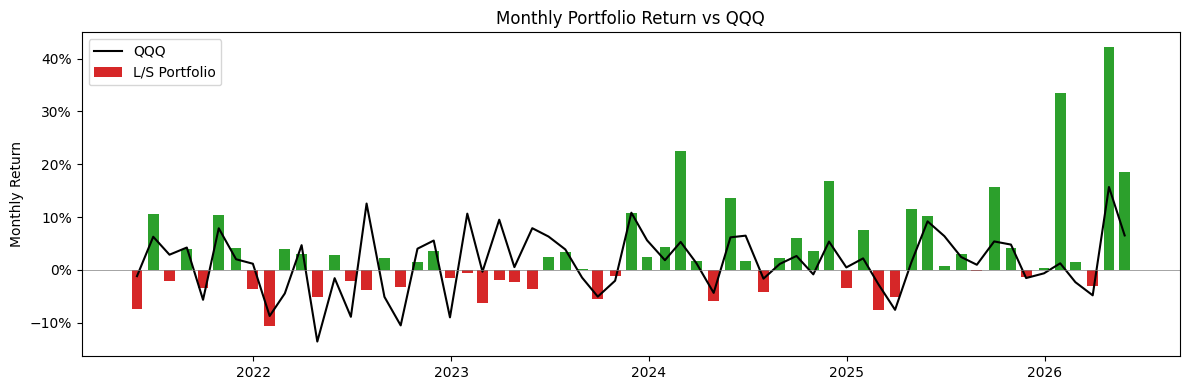

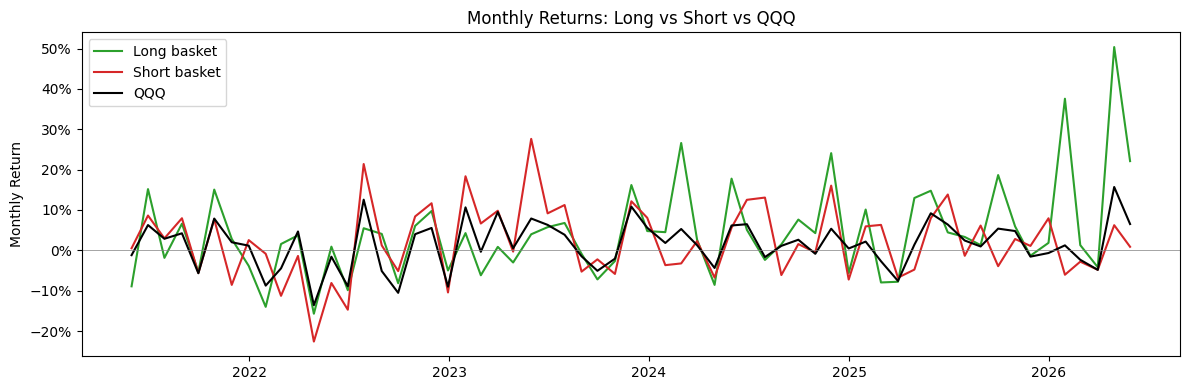

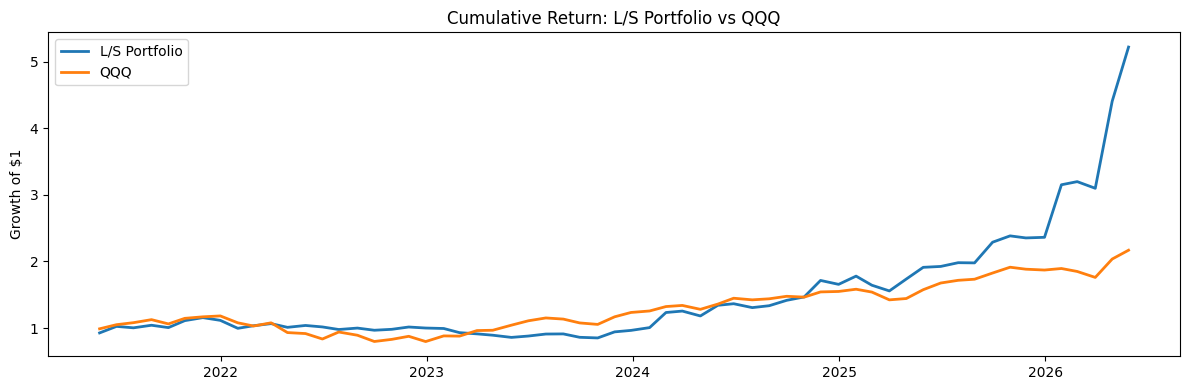

In [12]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Chart 1: monthly portfolio return as colored bars vs QQQ line.
fig, ax = plt.subplots(figsize=(12, 4))
port = bt.portfolio_returns
bar_colors = port.ge(0).map({True: "#2ca02c", False: "#d62728"})
ax.bar(port.index, port.values, width=20, color=bar_colors.values, label="L/S Portfolio")
ax.plot(bt.benchmark_returns.index, bt.benchmark_returns.values,
        color="black", linewidth=1.5, label="QQQ")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("Monthly Portfolio Return vs QQQ")
ax.set_ylabel("Monthly Return")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

# Chart 2: long picks vs short picks vs QQQ monthly returns.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bt.long_basket_returns.index,  bt.long_basket_returns.values,
        label="Long basket",  color="#2ca02c", linewidth=1.5)
ax.plot(bt.short_basket_returns.index, bt.short_basket_returns.values,
        label="Short basket", color="#d62728", linewidth=1.5)
ax.plot(bt.benchmark_returns.index,    bt.benchmark_returns.values,
        label="QQQ",          color="black",   linewidth=1.5)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("Monthly Returns: Long vs Short vs QQQ")
ax.set_ylabel("Monthly Return")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

# Chart 3: cumulative growth of $1 - L/S portfolio vs QQQ.
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bt.cumulative_portfolio.index, bt.cumulative_portfolio.values,
        label="L/S Portfolio", linewidth=2)
ax.plot(bt.cumulative_benchmark.index, bt.cumulative_benchmark.values,
        label="QQQ", linewidth=2)
ax.set_title("Cumulative Return: L/S Portfolio vs QQQ")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Reconstruct daily portfolio returns from daily prices + the monthly signals.
# We forward-fill month-end signals onto the daily grid, then shift by one day
# so a given day's return is earned on positions decided strictly before it
# (avoids lookahead on the rebalance day itself).
daily_returns = prices.pct_change()
sig_daily = signals.reindex(daily_returns.index, method="ffill").shift(1)

n_active = sig_daily.abs().sum(axis=1).replace(0, np.nan)
daily_port = (daily_returns * sig_daily).sum(axis=1) / n_active

# Clip to the same trailing window the backtest report uses, then compound
# daily P&L into Friday-ending weekly returns.
start = bt.portfolio_returns.index.min()
end = bt.portfolio_returns.index.max()
daily_port = daily_port.loc[start:end].fillna(0)
weekly_port = (1 + daily_port).resample("W-FRI").prod() - 1
weekly_port = weekly_port.loc[weekly_port.ne(0).cumsum() > 0]  # drop any leading empty weeks

# Pivot weekly returns into a Year x ISO-Week matrix for the heatmap.
iso = weekly_port.index.isocalendar()
heat = (
    pd.DataFrame({"Year": iso.year.values,
                  "Week": iso.week.values,
                  "Ret":  weekly_port.values})
      .pivot(index="Year", columns="Week", values="Ret")
      .reindex(columns=range(1, 54))
      .sort_index()
)

fig, ax = plt.subplots(figsize=(16, 0.6 * len(heat) + 2))
vmax = float(np.nanmax(np.abs(heat.values)))
im = ax.imshow(heat.values, aspect="auto", cmap="RdYlGn",
               vmin=-vmax, vmax=vmax, interpolation="nearest")

ax.set_xticks(range(0, 53, 2))
ax.set_xticklabels([str(w + 1) for w in range(0, 53, 2)])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([str(y) for y in heat.index])
ax.set_xlabel("ISO Week")
ax.set_ylabel("Year")
ax.set_title("Weekly L/S Portfolio Return Heatmap (Backtest Period)")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v * 100:.1f}", ha="center", va="center",
                    fontsize=6, color="black")

cbar = fig.colorbar(im, ax=ax, format=PercentFormatter(1.0))
cbar.set_label("Weekly Return")
plt.tight_layout()
plt.show()
